# ⚖️ Comparaison K-Means vs Modèle de Référence Simple (Quartiles de l'IIFT)
## Capstone G10 · Programme FRST/SDMIA · Faculté des Sciences, UEH

**Équipe (Groupe 10) :**
- **Jean Baptiste Kendy** — coordinateur
- **Louis Wilson Junior**
- **Jonathan Francois Alcena**

**Encadrant :** ING Evens Toussaint

---
**Étape 2.4 du planning.** Ce notebook prend la suite directe de l'ACP/IIFT (2.2) et du clustering
(2.3). Il compare la typologie K-Means déjà calculée à un modèle de référence très simple : une
classification des communes par quartiles de l'**IIFT déjà calculé**.

**Point méthodologique important :** ce notebook ne recalcule ni l'IIFT ni le K-Means. L'IIFT est
importé depuis `G10_iift_communes.csv` (notebook 2.2) et les clusters sont importés depuis
`G10_clusters_kmeans.csv` (notebook 2.3). La seule opération nouvelle est le découpage de l'IIFT
existant en quartiles pour construire une baseline lisible.

**Pourquoi cette comparaison est utile :** si les quartiles de l'IIFT donnent presque la même
partition que le K-Means, alors une règle simple suffit pour une classification de premier niveau.
Si les deux partitions diffèrent, le K-Means se justifie comme outil de profilage multivarié : il
apporte une lecture territoriale complémentaire à l'IIFT, sans remplacer l'indice cible utilisé plus
tard en section 2.5 pour la modélisation supervisée et la feature importance.

**Entrées** (dépôt GitHub, `output/tables/`) :
- `clustering_afcm_tables/G10_clusters_kmeans.csv` — clusters K-Means et coordonnées ACP (2.3)
- `acp_iift_tables/G10_iift_communes.csv` — IIFT déjà calculé (2.2)
- geojson des 140 communes, pour la cartographie comparative


---
## Section 0 (Cellule 1) — Installation, imports & configuration graphique


In [1]:
# ===========================================================================
#  SECTION 0 (Cellule 2) — INSTALLATION, IMPORTS & CONFIGURATION
# ===========================================================================

import sys
import subprocess
import importlib.util

# geopandas n'est pas toujours préinstallé sous Colab.
if importlib.util.find_spec("geopandas") is None:
    print("Installation de geopandas...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "geopandas", "-q"])

import os
import re
import warnings
import tempfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score,
)
from scipy import stats

from IPython.display import display

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid", font_scale=1.0)
COULEUR_PRINCIPALE = "#2C5F7C"
COULEUR_ACCENT = "#C0522D"
# Deux palettes DISTINCTES et volontairement différentes de celle des clusters
# K-Means (Set2, notebook 2.3) : ça évite qu'un même violet/vert soit lu comme
# "le même groupe" entre les deux partitions alors qu'elles n'ont aucune raison
# de s'aligner numéro à numéro.
PALETTE_KMEANS = "Set2"
PALETTE_QUARTILES = "flare"
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.family": "DejaVu Sans",
    "figure.dpi": 110,
})

SEED = 42
np.random.seed(SEED)

DOSSIER_TABLES = Path("output/tables/comparaison_tables")
DOSSIER_FIGURES = Path("output/figures")
DOSSIER_TABLES.mkdir(parents=True, exist_ok=True)
DOSSIER_FIGURES.mkdir(parents=True, exist_ok=True)

print("✅ Imports et configuration réussis")
print(f"   Colab   : {IN_COLAB}")
print(f"   Tables  : {DOSSIER_TABLES.resolve()}")
print(f"   Figures : {DOSSIER_FIGURES.resolve()}")


✅ Imports et configuration réussis
   Colab   : True
   Tables  : /content/output/tables/comparaison_tables
   Figures : /content/output/figures


---
## Section 1 (Cellule 3) — Chargement des données depuis GitHub


In [2]:
# ===========================================================================
#  SECTION 1 (Cellule 4) — CHEMINS & CHARGEMENT DES DONNÉES (dépôt GitHub)
# ===========================================================================

RACINE_GITHUB = "https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main"
DOSSIER_GITHUB_CLUSTERING = f"{RACINE_GITHUB}/output/tables/clustering_afcm_tables"
DOSSIER_GITHUB_ACP_IIFT = f"{RACINE_GITHUB}/output/tables/acp_iift_tables"

CHEMIN_CLUSTERS_KMEANS = f"{DOSSIER_GITHUB_CLUSTERING}/G10_clusters_kmeans.csv"
CHEMIN_CHOIX_K = f"{DOSSIER_GITHUB_CLUSTERING}/G10_choix_k_kmeans.csv"
CHEMIN_IIFT = f"{DOSSIER_GITHUB_ACP_IIFT}/G10_iift_communes.csv"
CHEMIN_GEOJSON = f"{RACINE_GITHUB}/data/raw/hti_admin_boundaries/hti_admin2.geojson"

print("=" * 65)
print("  SECTION 1 — VÉRIFICATION DES FICHIERS UTILISÉS (GitHub)")
print("=" * 65)

def verifier_accessible(chemin, label):
    try:
        requete = urllib.request.Request(chemin, method="HEAD")
        with urllib.request.urlopen(requete, timeout=15) as reponse:
            taille = int(reponse.headers.get("Content-Length", 0)) / 1024
        print(f"   ✅ {label:<18} accessible ({taille:.1f} Ko) : {chemin}")
        return True
    except Exception as e:
        print(f"   ❌ {label:<18} INACCESSIBLE : {chemin}")
        print(f"      → {e}")
        return False

for chemin, label in [
    (CHEMIN_CLUSTERS_KMEANS, "CLUSTERS_KM"), (CHEMIN_CHOIX_K, "CHOIX_K"),
    (CHEMIN_IIFT, "IIFT"), (CHEMIN_GEOJSON, "GEOJSON"),
]:
    verifier_accessible(chemin, label)

clusters_kmeans = pd.read_csv(CHEMIN_CLUSTERS_KMEANS, encoding="utf-8-sig")
choix_k = pd.read_csv(CHEMIN_CHOIX_K, encoding="utf-8-sig")
iift = pd.read_csv(CHEMIN_IIFT, encoding="utf-8-sig")

with urllib.request.urlopen(CHEMIN_GEOJSON, timeout=30) as reponse:
    geojson_bytes = reponse.read()
with tempfile.NamedTemporaryFile(suffix=".geojson", delete=False) as tmp:
    tmp.write(geojson_bytes)
    chemin_geojson_local = tmp.name
communes_geo = gpd.read_file(chemin_geojson_local).to_crs(epsg=4326)

print(f"\n✅ clusters_kmeans : {clusters_kmeans.shape[0]} communes × {clusters_kmeans.shape[1]} colonnes")
print(f"✅ iift            : {iift.shape[0]} communes × {iift.shape[1]} colonnes")
print(f"✅ communes_geo    : {len(communes_geo)} polygones")

display(clusters_kmeans.head(3))
display(iift.head(3))


  SECTION 1 — VÉRIFICATION DES FICHIERS UTILISÉS (GitHub)
   ✅ CLUSTERS_KM        accessible (24.5 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/clustering_afcm_tables/G10_clusters_kmeans.csv
   ✅ CHOIX_K            accessible (0.7 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/clustering_afcm_tables/G10_choix_k_kmeans.csv
   ✅ IIFT               accessible (14.1 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/output/tables/acp_iift_tables/G10_iift_communes.csv
   ✅ GEOJSON            accessible (2388.7 Ko) : https://raw.githubusercontent.com/Jean-Baptiste-Kendy/Projet_Capstone_G10/main/data/raw/hti_admin_boundaries/hti_admin2.geojson

✅ clusters_kmeans : 140 communes × 13 colonnes
✅ iift            : 140 communes × 8 colonnes
✅ communes_geo    : 140 polygones


,id_commune,nom_commune,arrondissement,adm2_pcode,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,cluster_kmeans,cluster_cha,niveau_iift
0,C-001,Port-au-Prince,Port-au-Prince,HT0111,10.041542,-3.258678,-4.131774,0.602384,0.226182,-1.316938,1,0,Classe_IIFT_Extrême
1,C-002,Delmas,Port-au-Prince,HT0112,9.727956,-1.867859,-4.137420,0.722036,0.688011,-1.632219,1,0,Classe_IIFT_Extrême
2,C-003,Cité Soleil,Port-au-Prince,HT0117,4.425251,0.169995,-2.679387,2.486033,2.501844,-1.677778,1,0,Classe_IIFT_Extrême


,id_commune,nom_commune,arrondissement,adm2_pcode,score_acp_dim1_oriente,IIFT,classe_IIFT,IIFT_multi_axes_robustesse
0,C-001,Port-au-Prince,Port-au-Prince,HT0111,10.041542,100.000000,Très élevé,96.904195
1,C-002,Delmas,Port-au-Prince,HT0112,9.727956,97.736443,Très élevé,100.000000
2,C-003,Cité Soleil,Port-au-Prince,HT0117,4.425251,59.459939,Très élevé,71.806599


---
## Section 2 (Cellule 5) — Contrôle qualité & fusion

Fusion de `clusters_kmeans` (K-Means + coordonnées Dim1-6, notebook 2.3) et `iift` (IIFT, classes,
notebook 2.2) sur `id_commune`, après vérification que les deux tables couvrent bien le même
ensemble de 140 communes.


In [3]:
# ===========================================================================
#  SECTION 2 (Cellule 6) — CONTRÔLE QUALITÉ & FUSION
# ===========================================================================

print("=" * 65)
print("  SECTION 2 — CONTRÔLE QUALITÉ")
print("=" * 65)

ids_clusters, ids_iift = set(clusters_kmeans["id_commune"]), set(iift["id_commune"])
print(f"   Communes clusters_kmeans : {len(ids_clusters)}")
print(f"   Communes iift            : {len(ids_iift)}")
print(f"   Différence (l'une sans l'autre) : {len(ids_clusters ^ ids_iift)}")
assert ids_clusters == ids_iift, "Les deux tables doivent porter sur les mêmes 140 communes"

axes_disponibles = [c for c in clusters_kmeans.columns if re.fullmatch(r"Dim\d+", c)]
print(f"   Axes ACP disponibles dans clusters_kmeans : {axes_disponibles}")

df = clusters_kmeans.merge(
    iift.drop(columns=["nom_commune", "arrondissement", "adm2_pcode"]), on="id_commune", how="inner"
)
assert df.shape[0] == 140

K_KMEANS = df["cluster_kmeans"].nunique()
print(f"\n✅ Table fusionnée : {df.shape[0]} communes × {df.shape[1]} colonnes")
print(f"✅ K-Means utilise K={K_KMEANS} clusters (repris du notebook 2.3)")

display(df[["nom_commune", "cluster_kmeans", "IIFT", "classe_IIFT"] + axes_disponibles[:2]].head(5))


  SECTION 2 — CONTRÔLE QUALITÉ
   Communes clusters_kmeans : 140
   Communes iift            : 140
   Différence (l'une sans l'autre) : 0
   Axes ACP disponibles dans clusters_kmeans : ['Dim1', 'Dim2', 'Dim3', 'Dim4', 'Dim5', 'Dim6']

✅ Table fusionnée : 140 communes × 17 colonnes
✅ K-Means utilise K=3 clusters (repris du notebook 2.3)


,nom_commune,cluster_kmeans,IIFT,classe_IIFT,Dim1,Dim2
0,Port-au-Prince,1,100.000000,Très élevé,10.041542,-3.258678
1,Delmas,1,97.736443,Très élevé,9.727956,-1.867859
2,Cité Soleil,1,59.459939,Très élevé,4.425251,0.169995
3,Tabarre,1,71.442514,Très élevé,6.085279,-1.441390
4,Carrefour,1,86.218616,Très élevé,8.132313,-1.670765


---
## Section 3 (Cellule 7) — Construction du modèle de référence simple

Le modèle de référence est volontairement naïf : on découpe l'**IIFT déjà calculé** en 4 groupes de
taille proche (quartiles). On ne crée pas un nouvel indice et on ne refait pas l'ACP : on transforme
seulement l'indice existant en classes simples pour disposer d'un point de comparaison face au
K-Means.


  SECTION 3 — QUARTILES DE L'IIFT (MODÈLE DE RÉFÉRENCE)
   ℹ️ La colonne classe_IIFT existe déjà dans le fichier IIFT.
   Taille des groupes (quartiles, cible ≈ 35 communes chacun) :


,nb_communes
quartile_iift,
Q1 — Faible,35
Q2 — Moyen-faible,35
Q3 — Moyen-élevé,35
Q4 — Élevé,35



   Bornes IIFT par quartile :


,min,max
quartile_iift,,
Q1 — Faible,0.0,10.2
Q2 — Moyen-faible,10.2,22.9
Q3 — Moyen-élevé,23.0,35.3
Q4 — Élevé,35.6,100.0


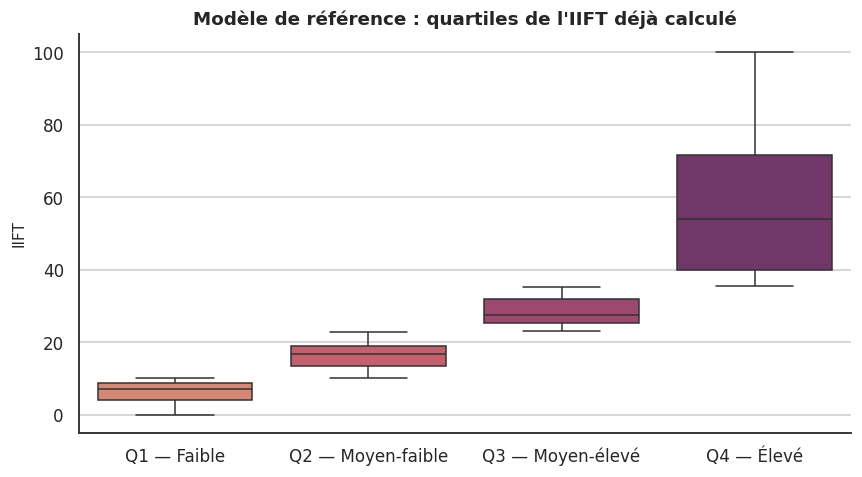


ℹ️ Le modèle de référence produit 4 groupes, le K-Means importé en produit 3.


In [4]:
# ===========================================================================
#  SECTION 3 (Cellule 8) — MODÈLE DE RÉFÉRENCE : QUARTILES DE L'IIFT EXISTANT
# ===========================================================================

print("=" * 65)
print("  SECTION 3 — QUARTILES DE L'IIFT (MODÈLE DE RÉFÉRENCE)")
print("=" * 65)

LABELS_QUARTILES = ["Q1 — Faible", "Q2 — Moyen-faible", "Q3 — Moyen-élevé", "Q4 — Élevé"]

if "classe_IIFT" in df.columns:
    print("   ℹ️ La colonne classe_IIFT existe déjà dans le fichier IIFT.")

df["quartile_iift"] = pd.qcut(df["IIFT"], q=4, labels=LABELS_QUARTILES)

tailles_quartiles = df["quartile_iift"].value_counts().sort_index()
print("   Taille des groupes (quartiles, cible ≈ 35 communes chacun) :")
display(tailles_quartiles.rename("nb_communes"))

bornes_quartiles = df.groupby("quartile_iift")["IIFT"].agg(["min", "max"]).round(1)
print("\n   Bornes IIFT par quartile :")
display(bornes_quartiles)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x="quartile_iift", y="IIFT", hue="quartile_iift",
            palette=PALETTE_QUARTILES, legend=False, order=LABELS_QUARTILES, ax=ax)
ax.set_title("Modèle de référence : quartiles de l'IIFT déjà calculé")
ax.set_xlabel("")
sns.despine()
plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_quartiles_iift.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nℹ️ Le modèle de référence produit {df['quartile_iift'].nunique()} groupes, "
      f"le K-Means importé en produit {K_KMEANS}.")


---
## Section 4 (Cellule 9) — Comparaison structurelle des deux partitions

Deux indices d'accord entre partitions :
- **ARI (Adjusted Rand Index)** : accord sur les paires de communes, corrigé du hasard.
- **NMI (Normalized Mutual Information)** : information mutuelle normalisée entre les partitions.

Un accord élevé signifierait que le K-Means redécouvre surtout le classement par IIFT. Un accord
modéré ou faible indique que le K-Means apporte une structure complémentaire utile pour le profilage
territorial.


  SECTION 4 — ACCORD ENTRE K-MEANS ET QUARTILES IIFT
   Adjusted Rand Index (ARI) : 0.255
   Normalized Mutual Info (NMI) : 0.389

   → Accord faible : le K-Means capture une structure territoriale sensiblement différente du simple classement par IIFT.

   Tableau croisé cluster K-Means × quartile IIFT :


quartile_iift,Q1 — Faible,Q2 — Moyen-faible,Q3 — Moyen-élevé,Q4 — Élevé
cluster_kmeans,,,,
0,35,26,12,1
1,0,0,0,17
2,0,9,23,17


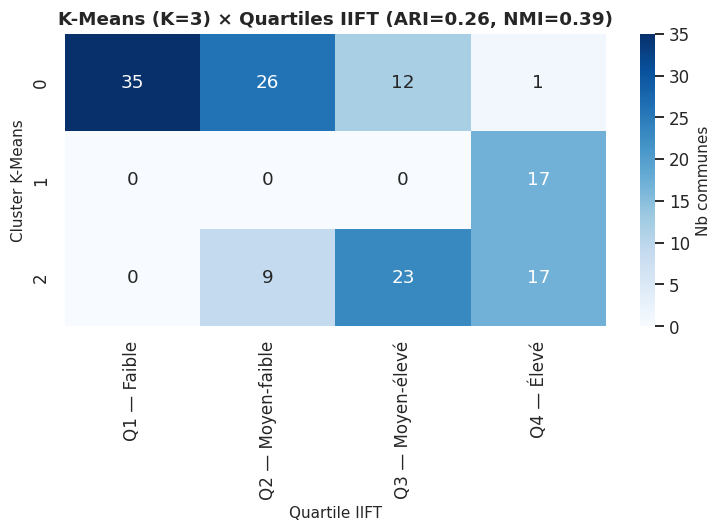

In [5]:
# ===========================================================================
#  SECTION 4 (Cellule 10) — COMPARAISON STRUCTURELLE DES PARTITIONS
# ===========================================================================

print("=" * 65)
print("  SECTION 4 — ACCORD ENTRE K-MEANS ET QUARTILES IIFT")
print("=" * 65)

ari = adjusted_rand_score(df["cluster_kmeans"], df["quartile_iift"])
nmi = normalized_mutual_info_score(df["cluster_kmeans"], df["quartile_iift"])

print(f"   Adjusted Rand Index (ARI) : {ari:.3f}")
print(f"   Normalized Mutual Info (NMI) : {nmi:.3f}")

if nmi >= 0.7:
    verdict = ("Accord fort : les quartiles de l'IIFT capturent déjà une grande partie de la "
               "structure. Le K-Means se justifie surtout pour le profilage fin.")
elif nmi >= 0.4:
    verdict = ("Accord modéré : les deux partitions se recoupent, mais le K-Means ajoute des "
               "nuances que l'IIFT seul ne voit pas.")
else:
    verdict = ("Accord faible : le K-Means capture une structure territoriale sensiblement "
               "différente du simple classement par IIFT.")
print(f"\n   → {verdict}")

tableau_croise = pd.crosstab(df["cluster_kmeans"], df["quartile_iift"])
print("\n   Tableau croisé cluster K-Means × quartile IIFT :")
display(tableau_croise)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(tableau_croise, annot=True, fmt="d", cmap="Blues",
            cbar_kws={"label": "Nb communes"}, ax=ax)
ax.set_title(f"K-Means (K={K_KMEANS}) × Quartiles IIFT (ARI={ari:.2f}, NMI={nmi:.2f})")
ax.set_xlabel("Quartile IIFT")
ax.set_ylabel("Cluster K-Means")
plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_comparaison_partitions_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Section 5 (Cellule 11) — Qualité de séparation dans l'espace ACP

On compare les deux partitions dans l'espace ACP déjà disponible dans `G10_clusters_kmeans.csv`.
Cette étape ne refait pas l'ACP : elle mesure seulement si les quartiles de l'IIFT séparent les
communes aussi bien que le K-Means dans l'espace multivarié utilisé pour le profilage.


  SECTION 5 — SILHOUETTE COMPARÉE SUR L'ESPACE ACP
   Silhouette K-Means (sur Dim1-Dim6) : 0.336
   Silhouette Quartiles IIFT (même espace) : 0.079
   Écart relatif : +325%

   eta² par axe (part de variance expliquée par chaque partition) :


,axe,eta2_kmeans,eta2_quartiles_iift
0,Dim1,0.800,0.790
1,Dim2,0.714,0.091
2,Dim3,0.032,0.070
3,Dim4,0.004,0.024
4,Dim5,0.003,0.077
5,Dim6,0.002,0.013


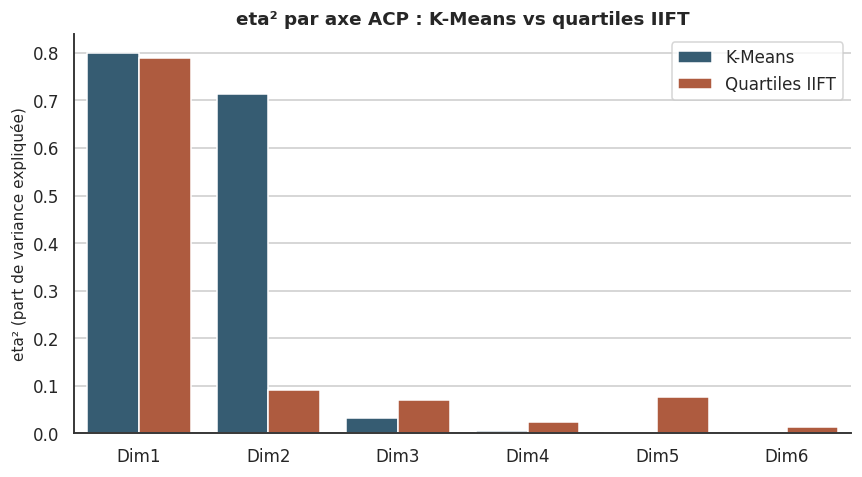

In [6]:
# ===========================================================================
#  SECTION 5 (Cellule 12) — POUVOIR EXPLICATIF SUR L'ESPACE ACP EXISTANT
# ===========================================================================

print("=" * 65)
print("  SECTION 5 — SILHOUETTE COMPARÉE SUR L'ESPACE ACP")
print("=" * 65)

X_axes = df[axes_disponibles].to_numpy()

silhouette_kmeans = silhouette_score(X_axes, df["cluster_kmeans"])
silhouette_quartiles = silhouette_score(X_axes, df["quartile_iift"])

print(f"   Silhouette K-Means (sur {axes_disponibles[0]}-{axes_disponibles[-1]}) : {silhouette_kmeans:.3f}")
print(f"   Silhouette Quartiles IIFT (même espace) : {silhouette_quartiles:.3f}")
ecart_pct = 100 * (silhouette_kmeans - silhouette_quartiles) / abs(silhouette_quartiles) if silhouette_quartiles != 0 else np.nan
print(f"   Écart relatif : {ecart_pct:+.0f}%")

def eta_carre(groupes):
    moyenne_globale = np.concatenate(groupes).mean()
    sce_inter = sum(len(g) * (g.mean() - moyenne_globale) ** 2 for g in groupes)
    sce_totale = sum(((g - moyenne_globale) ** 2).sum() for g in groupes)
    return sce_inter / sce_totale if sce_totale > 0 else np.nan

resultats_eta2 = []
for axe in axes_disponibles:
    groupes_km = [df.loc[df["cluster_kmeans"] == k, axe].values for k in sorted(df["cluster_kmeans"].unique())]
    groupes_q = [df.loc[df["quartile_iift"] == q, axe].values for q in LABELS_QUARTILES]
    resultats_eta2.append({
        "axe": axe,
        "eta2_kmeans": eta_carre(groupes_km),
        "eta2_quartiles_iift": eta_carre(groupes_q),
    })

tbl_eta2 = pd.DataFrame(resultats_eta2)
print("\n   eta² par axe (part de variance expliquée par chaque partition) :")
display(tbl_eta2.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
tbl_eta2_long = tbl_eta2.melt(id_vars="axe", value_vars=["eta2_kmeans", "eta2_quartiles_iift"],
                              var_name="partition", value_name="eta2")
tbl_eta2_long["partition"] = tbl_eta2_long["partition"].map({
    "eta2_kmeans": "K-Means", "eta2_quartiles_iift": "Quartiles IIFT"
})
sns.barplot(data=tbl_eta2_long, x="axe", y="eta2", hue="partition",
            palette=[COULEUR_PRINCIPALE, COULEUR_ACCENT], ax=ax)
ax.set_title("eta² par axe ACP : K-Means vs quartiles IIFT")
ax.set_ylabel("eta² (part de variance expliquée)")
ax.set_xlabel("")
ax.legend(title="")
sns.despine()
plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_eta2_kmeans_vs_quartiles_iift.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Section 6 (Cellule 13) — Valeur ajoutée concrète : communes invisibles pour le modèle simple

Les cas les plus parlants pour le rapport : des communes dans le même quartile IIFT mais placées
dans des clusters K-Means différents. Cela montre que le clustering apporte un profilage
complémentaire sans créer un nouvel indice.


  SECTION 6 — HÉTÉROGÉNÉITÉ MASQUÉE PAR LES QUARTILES IIFT
   Nombre de clusters K-Means distincts par quartile IIFT :


,nb_clusters_kmeans_distincts
quartile_iift,
Q1 — Faible,1
Q2 — Moyen-faible,2
Q3 — Moyen-élevé,2
Q4 — Élevé,3



   ✅ Au moins un quartile IIFT contient plusieurs clusters K-Means :
      l'IIFT seul masque une hétérogénéité territoriale que le clustering distingue.

🔍 Exemple — quartile 'Q4 — Élevé' (3 clusters K-Means différents) :


,nom_commune,IIFT,quartile_iift,cluster_kmeans,Dim1,Dim2,Dim3,Dim4
81,Mirebalais,39.602569,Q4 — Élevé,0,1.674273,-3.604788,1.521407,-1.209517
0,Port-au-Prince,100.000000,Q4 — Élevé,1,10.041542,-3.258678,-4.131774,0.602384
2,Cité Soleil,59.459939,Q4 — Élevé,1,4.425251,0.169995,-2.679387,2.486033
1,Delmas,97.736443,Q4 — Élevé,1,9.727956,-1.867859,-4.137420,0.722036
4,Carrefour,86.218616,Q4 — Élevé,1,8.132313,-1.670765,-1.522907,0.790299
5,Pétion-Ville,92.683450,Q4 — Élevé,1,9.027931,-2.946373,-1.854825,-1.798893
8,Léogâne,72.184257,Q4 — Élevé,1,6.188037,-0.763570,1.709820,-0.857216
3,Tabarre,71.442514,Q4 — Élevé,1,6.085279,-1.441390,-3.198570,1.697963
20,Jacmel,54.268829,Q4 — Élevé,1,3.706091,-4.872538,0.856214,-2.296895
11,Croix-des-Bouquets,70.658350,Q4 — Élevé,1,5.976643,-1.994308,1.715794,-0.094595


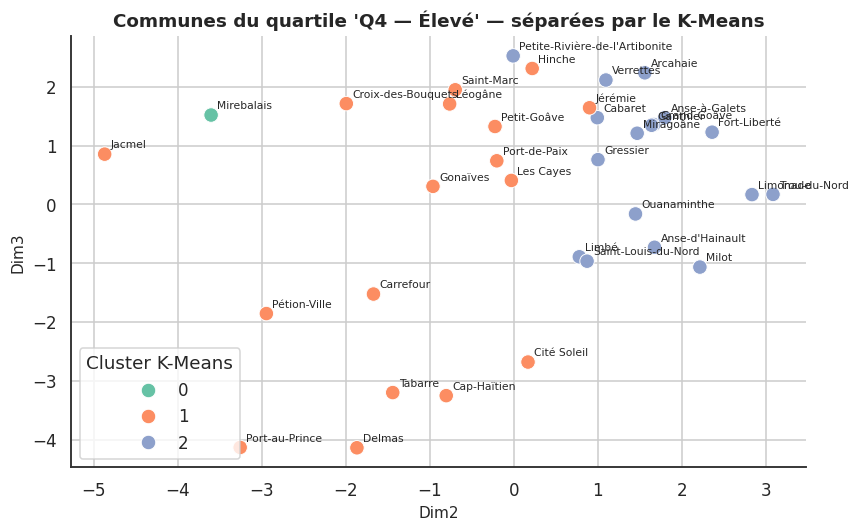

In [7]:
# ===========================================================================
#  SECTION 6 (Cellule 14) — VALEUR AJOUTÉE CONCRÈTE DU CLUSTERING
# ===========================================================================

print("=" * 65)
print("  SECTION 6 — HÉTÉROGÉNÉITÉ MASQUÉE PAR LES QUARTILES IIFT")
print("=" * 65)

diversite_par_quartile = df.groupby("quartile_iift")["cluster_kmeans"].nunique().reindex(LABELS_QUARTILES)
print("   Nombre de clusters K-Means distincts par quartile IIFT :")
display(diversite_par_quartile.rename("nb_clusters_kmeans_distincts"))

if (diversite_par_quartile > 1).any():
    print("\n   ✅ Au moins un quartile IIFT contient plusieurs clusters K-Means :")
    print("      l'IIFT seul masque une hétérogénéité territoriale que le clustering distingue.")
else:
    print("\n   ⚠️ Chaque quartile IIFT correspond à un unique cluster K-Means :")
    print("      dans ce cas, le modèle simple suffirait presque à reproduire la typologie.")

quartile_exemple = diversite_par_quartile.idxmax()
sous_ensemble = df.loc[df["quartile_iift"] == quartile_exemple,
                        ["nom_commune", "IIFT", "quartile_iift", "cluster_kmeans"] + axes_disponibles[:4]]
sous_ensemble = sous_ensemble.sort_values("cluster_kmeans")

print(f"\n🔍 Exemple — quartile '{quartile_exemple}' "
      f"({diversite_par_quartile[quartile_exemple]} clusters K-Means différents) :")
display(sous_ensemble)

# Dim2 x Dim3 plutôt que Dim1 x Dim2 : ces communes sont volontairement dans le
# MÊME quartile IIFT (donc très proches sur Dim1, l'axe qui structure l'IIFT) —
# les projeter sur Dim1 les superposerait presque toutes. Dim2/Dim3 sont les
# axes qui les séparent réellement, donc ceux qui montrent concrètement ce que
# le K-Means voit et que le classement par IIFT (univarié, basé sur Dim1) ne
# voit pas. Repli sur Dim2 si Dim3 est absent (cas limite non attendu ici, vu
# que le clustering utilise au moins 6 axes, mais gardé par sécurité).
fig, ax = plt.subplots(figsize=(8, 5))
sous_df = df.loc[df["quartile_iift"] == quartile_exemple]
axe_y_secondaire = "Dim3" if "Dim3" in axes_disponibles else "Dim2"
sns.scatterplot(
    data=sous_df, x="Dim2", y=axe_y_secondaire,
    hue="cluster_kmeans", palette=PALETTE_KMEANS, s=90, edgecolor="white", linewidth=0.6, ax=ax,
)
for _, ligne in sous_df.iterrows():
    ax.annotate(ligne["nom_commune"], (ligne["Dim2"], ligne[axe_y_secondaire]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_title(f"Communes du quartile '{quartile_exemple}' — séparées par le K-Means")
ax.legend(title="Cluster K-Means")
sns.despine()
plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_heterogeneite_quartile_iift_exemple.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Section 7 (Cellule 15) — Plan factoriel comparé (Dim1 × Dim2)

Les deux partitions sont projetées côte à côte sur le même plan `Dim1 × Dim2`. La classification par
seuils donne une lecture mécanique, issue des rangs-quartiles ; le K-Means peut former des groupes
qui suivent davantage la géométrie du nuage.


  SECTION 7 — PLAN FACTORIEL Dim1 × Dim2 : K-MEANS vs QUARTILES IIFT


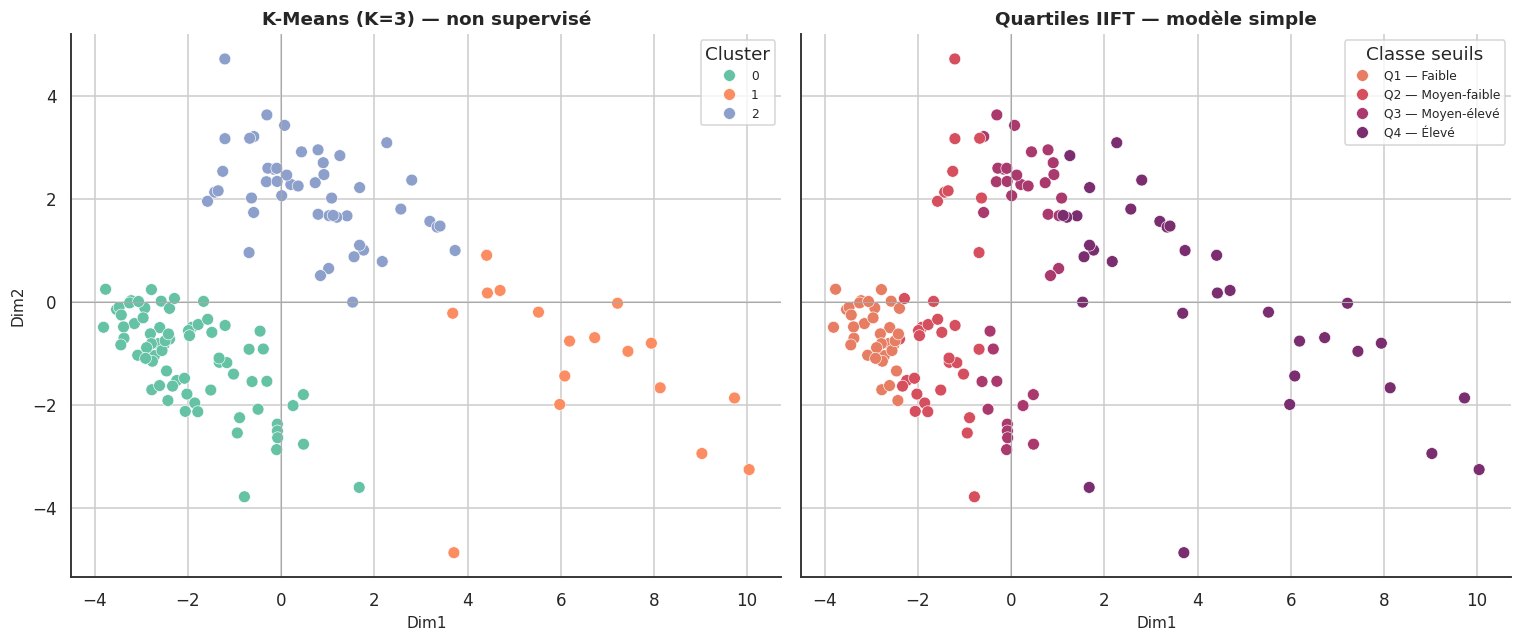

In [8]:
# ===========================================================================
#  SECTION 7 (Cellule 16) — PLAN FACTORIEL COMPARÉ
# ===========================================================================

print("=" * 65)
print("  SECTION 7 — PLAN FACTORIEL Dim1 × Dim2 : K-MEANS vs QUARTILES IIFT")
print("=" * 65)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.scatterplot(data=df, x="Dim1", y="Dim2", hue="cluster_kmeans", palette=PALETTE_KMEANS,
                 s=60, edgecolor="white", linewidth=0.4, ax=ax1, legend="full")
ax1.set_title(f"K-Means (K={K_KMEANS}) — non supervisé")
ax1.legend(title="Cluster", loc="best", fontsize=8)

sns.scatterplot(data=df, x="Dim1", y="Dim2", hue="quartile_iift",
                 palette=PALETTE_QUARTILES, hue_order=LABELS_QUARTILES,
                 s=60, edgecolor="white", linewidth=0.4, ax=ax2, legend="full")
ax2.set_title("Quartiles IIFT — modèle simple")
ax2.legend(title="Classe seuils", loc="best", fontsize=8)

for ax in (ax1, ax2):
    sns.despine(ax=ax)
    ax.axhline(0, color="#AAAAAA", linewidth=0.7)
    ax.axvline(0, color="#AAAAAA", linewidth=0.7)

plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_plan_factoriel_kmeans_vs_seuils.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Section 8 (Cellule 17) — Cartographie comparée

Deux cartes choroplèthes côte à côte, mêmes 140 communes : une lecture géographique directe des
deux typologies. Une différence marquée entre les deux cartes illustre concrètement ce que le
K-Means gagne par rapport à des seuils fixes appliqués aux mêmes axes.


  SECTION 8 — CARTES K-MEANS vs QUARTILES IIFT
   Communes du geojson sans correspondance dans df : 0


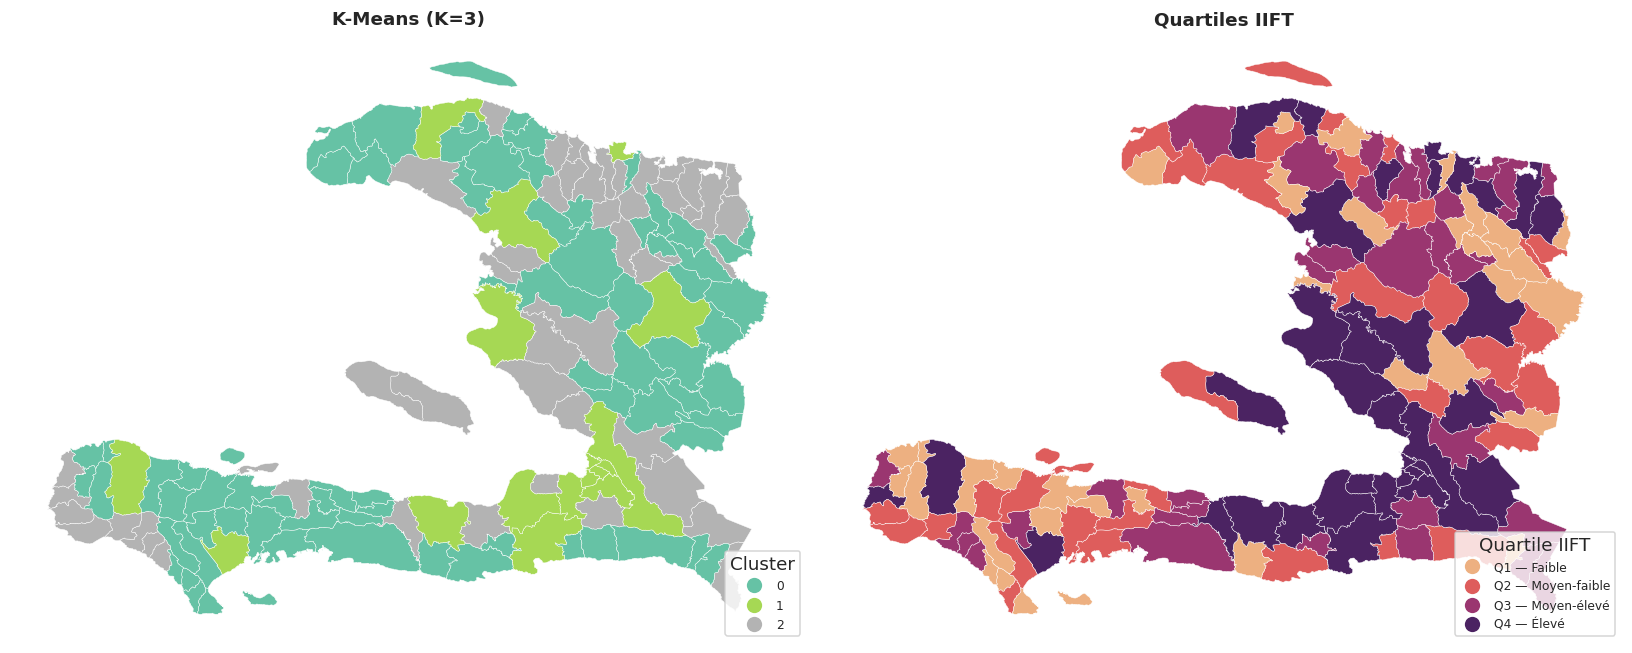

In [9]:
# ===========================================================================
#  SECTION 8 (Cellule 18) — CARTOGRAPHIE COMPARÉE
# ===========================================================================

print("=" * 65)
print("  SECTION 8 — CARTES K-MEANS vs QUARTILES IIFT")
print("=" * 65)

# Jointure sur adm2_pcode (code administratif standard), pas sur le nom de la
# commune : plus fiable, la normalisation de texte (accents, tirets) n'entre
# pas en jeu ici puisque df porte déjà adm2_pcode depuis sa fusion (Section 2).
communes_carte = communes_geo.merge(
    df[["adm2_pcode", "cluster_kmeans", "quartile_iift", "IIFT"]],
    on="adm2_pcode",
    how="left",
)
# Contrôle de cohérence avant de tracer : si ce nombre n'est pas 0, une partie
# de la carte s'affichera en gris ("Non apparié") sans que ce soit un bug du
# graphique — le problème serait alors dans la jointure elle-même, à vérifier
# ci-dessus plutôt que dans le code de tracé qui suit.
n_non_apparies = communes_carte["cluster_kmeans"].isna().sum()
print(f"   Communes du geojson sans correspondance dans df : {n_non_apparies}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Carte de gauche : la typologie K-Means, telle qu'importée du notebook 2.3.
communes_carte.plot(
    column="cluster_kmeans", categorical=True, cmap=PALETTE_KMEANS, legend=True,
    edgecolor="white", linewidth=0.3, ax=ax1,
    missing_kwds={"color": "#DDDDDD", "label": "Non apparié"},
    legend_kwds={"title": "Cluster", "fontsize": 8, "loc": "lower right"},
)
ax1.set_title(f"K-Means (K={K_KMEANS})")
ax1.axis("off")

# Carte de droite : le modèle de référence (quartiles de l'IIFT), même palette
# de type "categorical=True" mais une palette différente (PALETTE_QUARTILES,
# cf. Section 0) pour qu'un lecteur ne confonde jamais les deux légendes au
# premier coup d'œil, même en feuilletant le rapport imprimé en noir et blanc.
communes_carte.plot(
    column="quartile_iift", categorical=True, cmap=PALETTE_QUARTILES, legend=True,
    edgecolor="white", linewidth=0.3, ax=ax2,
    missing_kwds={"color": "#DDDDDD", "label": "Non apparié"},
    legend_kwds={"title": "Quartile IIFT", "fontsize": 8, "loc": "lower right"},
)
ax2.set_title("Quartiles IIFT")
ax2.axis("off")

plt.tight_layout()
fig.savefig(DOSSIER_FIGURES / "G10_cartes_kmeans_vs_seuils_quartiles.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Section 9 (Cellule 19) — Synthèse méthodologique pour le rapport

Récapitulatif chiffré de la comparaison, à reprendre directement dans la section méthodologie du
rapport pour justifier le choix entre clustering multivarié et classification simple par seuils.


In [10]:
# ===========================================================================
#  SECTION 9 (Cellule 20) — SYNTHÈSE MÉTHODOLOGIQUE
# ===========================================================================

print("=" * 65)
print("  SECTION 9 — SYNTHÈSE POUR LE RAPPORT")
print("=" * 65)

# Les lignes ci-dessous se répartissent en deux familles, à ne pas confondre :
# - lignes "par méthode" (silhouette, taille...) : une valeur DIFFÉRENTE par colonne,
#   puisque kmeans et quartiles_iift sont deux partitions distinctes des communes.
# - ARI et NMI sont des mesures de la RELATION entre les deux partitions (symétriques :
#   ARI(kmeans, quartiles) = ARI(quartiles, kmeans)) — une seule valeur existe, pas une
#   par méthode. La dupliquer dans les deux colonnes suggérerait à tort que chaque
#   partition a "son" ARI, ce qui n'a pas de sens ; on l'affiche donc une seule fois,
#   dans la colonne kmeans, avec un renvoi explicite dans quartiles_iift.
synthese = pd.DataFrame([
    {"critere": "Nombre de groupes", "kmeans": K_KMEANS, "quartiles_iift": 4},
    {"critere": "Données utilisées", "kmeans": "Clusters importés du notebook 2.3",
     "quartiles_iift": "IIFT importé du notebook 2.2"},
    {"critere": "Nouvel indice créé ?", "kmeans": "Non", "quartiles_iift": "Non"},
    {"critere": "Silhouette (espace ACP existant)", "kmeans": round(silhouette_kmeans, 3),
     "quartiles_iift": round(silhouette_quartiles, 3)},
    {"critere": "ARI entre les deux partitions (mesure symétrique)",
     "kmeans": round(ari, 3), "quartiles_iift": "idem (mesure unique, cf. kmeans)"},
    {"critere": "NMI entre les deux partitions (mesure symétrique)",
     "kmeans": round(nmi, 3), "quartiles_iift": "idem (mesure unique, cf. kmeans)"},
    {"critere": "Quartiles IIFT hétérogènes",
     "kmeans": f"{(diversite_par_quartile > 1).sum()}/{len(LABELS_QUARTILES)} quartiles contiennent plusieurs clusters",
     "quartiles_iift": "—"},
])
display(synthese)

texte_rapport = f"""
Conclusion méthodologique :

La comparaison ne recalcule ni l'IIFT ni le K-Means. L'IIFT est repris du notebook 2.2 et les
clusters K-Means sont repris du notebook 2.3. Le modèle simple consiste uniquement à découper l'IIFT
existant en quartiles.

Le score de silhouette du K-Means est de {silhouette_kmeans:.3f}, contre {silhouette_quartiles:.3f}
pour les quartiles IIFT dans le même espace ACP. L'accord entre les deux partitions est ARI={ari:.3f}
et NMI={nmi:.3f}. Si cet accord n'est pas très élevé, le K-Means apporte une information de profilage
complémentaire à l'IIFT : il ne remplace pas l'indice cible utilisé en section 2.5, mais aide à
décrire des groupes territoriaux que le classement univarié par IIFT peut masquer.
"""

print(texte_rapport)


  SECTION 9 — SYNTHÈSE POUR LE RAPPORT


,critere,kmeans,quartiles_iift
0,Nombre de groupes,3,4
1,Données utilisées,Clusters importés du notebook 2.3,IIFT importé du notebook 2.2
2,Nouvel indice créé ?,Non,Non
3,Silhouette (espace ACP existant),0.336,0.079
4,ARI entre les deux partitions (mesure symétrique),0.255,"idem (mesure unique, cf. kmeans)"
5,NMI entre les deux partitions (mesure symétrique),0.389,"idem (mesure unique, cf. kmeans)"
6,Quartiles IIFT hétérogènes,3/4 quartiles contiennent plusieurs clusters,—



Conclusion méthodologique :

La comparaison ne recalcule ni l'IIFT ni le K-Means. L'IIFT est repris du notebook 2.2 et les
clusters K-Means sont repris du notebook 2.3. Le modèle simple consiste uniquement à découper l'IIFT
existant en quartiles.

Le score de silhouette du K-Means est de 0.336, contre 0.079
pour les quartiles IIFT dans le même espace ACP. L'accord entre les deux partitions est ARI=0.255
et NMI=0.389. Si cet accord n'est pas très élevé, le K-Means apporte une information de profilage
complémentaire à l'IIFT : il ne remplace pas l'indice cible utilisé en section 2.5, mais aide à
décrire des groupes territoriaux que le classement univarié par IIFT peut masquer.



---
## Section 10 (Cellule 21) — Exports des résultats


In [11]:
# ===========================================================================
#  SECTION 10 (Cellule 22) — EXPORTS
# ===========================================================================

print("=" * 65)
print("  SECTION 10 — EXPORTS")
print("=" * 65)

exports = {
    "G10_comparaison_kmeans_quartiles_iift.csv": df[["id_commune", "nom_commune", "arrondissement",
                                                      "cluster_kmeans", "quartile_iift", "IIFT"] + axes_disponibles],
    "G10_tableau_croise_kmeans_quartiles_iift.csv": tableau_croise.reset_index(),
    "G10_eta2_kmeans_vs_quartiles_iift.csv": tbl_eta2,
    "G10_synthese_kmeans_vs_quartiles_iift.csv": synthese,
}

for nom_fichier, table in exports.items():
    chemin = DOSSIER_TABLES / nom_fichier
    table.to_csv(chemin, index=False, encoding="utf-8-sig")
    print(f"✅ {nom_fichier} exporté — {table.shape[0]} lignes × {table.shape[1]} colonnes")

print(f"\n✅ Exports terminés dans {DOSSIER_TABLES}/")

import shutil

fichiers_figures = sorted(DOSSIER_FIGURES.glob("*.png"))
print(f"\n📊 {len(fichiers_figures)} figure(s) HD trouvée(s) dans '{DOSSIER_FIGURES}/'")

if fichiers_figures:
    chemin_zip_base = "G10_Comparaison_KMeans_Quartiles_IIFT_figures_HD"
    chemin_zip = shutil.make_archive(chemin_zip_base, "zip", DOSSIER_FIGURES)
    taille_mo = os.path.getsize(chemin_zip) / (1024 * 1024)
    print(f"✅ {chemin_zip} créé ({taille_mo:.1f} Mo, {len(fichiers_figures)} image(s))")
else:
    chemin_zip = None
    print("⚠️ Aucune figure trouvée — relancez les sections avec graphiques avant cette cellule.")

if IN_COLAB:
    from google.colab import files
    for nom_fichier in exports:
        files.download(str(DOSSIER_TABLES / nom_fichier))
    if chemin_zip:
        files.download(chemin_zip)
    print("\n✅ Téléchargements Colab lancés (tables CSV + zip de figures)")
else:
    print(f"\nℹ️ Hors Colab : récupérez directement les fichiers dans '{DOSSIER_TABLES}/', "
          f"'{DOSSIER_FIGURES}/'" + (f" (ou le zip '{chemin_zip}')" if chemin_zip else ""))


  SECTION 10 — EXPORTS
✅ G10_comparaison_kmeans_quartiles_iift.csv exporté — 140 lignes × 12 colonnes
✅ G10_tableau_croise_kmeans_quartiles_iift.csv exporté — 3 lignes × 5 colonnes
✅ G10_eta2_kmeans_vs_quartiles_iift.csv exporté — 6 lignes × 3 colonnes
✅ G10_synthese_kmeans_vs_quartiles_iift.csv exporté — 7 lignes × 3 colonnes

✅ Exports terminés dans output/tables/comparaison_tables/

📊 6 figure(s) HD trouvée(s) dans 'output/figures/'
✅ /content/G10_Comparaison_KMeans_Quartiles_IIFT_figures_HD.zip créé (1.6 Mo, 6 image(s))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Téléchargements Colab lancés (tables CSV + zip de figures)
